In [1]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import scienceplots

plt.style.use('science')

import numpy as np

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

from pycbc.psd.analytical import aLIGO140MpcT1800545

PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


In [2]:
import sys
sys.path.insert(1, '../../detectability')

import resonance
from resonance import Filter, phase_diff_t_shift, phase_shift #System, 

In [3]:
import os

figures_path = '../figures/I'
os.makedirs(figures_path, exist_ok=True) 

In [4]:
f_low, f_high, tlen, srate, dL, approximant, detector = [15, 512, 512, 1024, 100, 'IMRPhenomD', 'aLIGO/AplusDesign']

filt = Filter(f_low, f_high, tlen, srate, dL, approximant, detector)

/home/alberto/ns-resonance/jupyter-env/lib/python3.12/site-packages/pycbc/types/array.py:390: RuntimeWarning: divide by zero encountered in divide
  return self._data.__rtruediv__(other)


In [5]:
frequency_colors = {50: 'red', 100: 'blue'}

freqs = list(frequency_colors.keys())

colors = list(frequency_colors.values())


In [6]:
def match_plot(fres, dPsi, dx_arr, color):
    match_PyCBC_arr, match_approx_arr, match_finer_arr = filt.match_dx(fres, dPsi, dx_arr)
    plt.plot(-dx_arr, match_approx_arr,'-.', color=color)
    plt.plot(-dx_arr, match_PyCBC_arr, ':', color=color)
    plt.plot(-dx_arr, match_finer_arr, alpha=0.5, color=color)

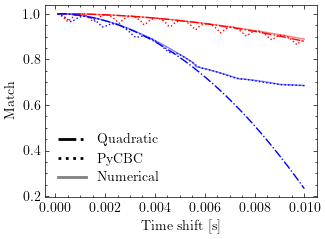

In [7]:
length_arr = 101
dt_arr = -np.linspace(1e-4, 1e-2, length_arr)

plt.figure(figsize=(3.5, 2.5))
[match_plot(fres, phase_diff_t_shift, dt_arr, color) for fres, color in frequency_colors.items()]
#plt.yscale('log') 

line_types = {'-.': 'Quadratic',':':'PyCBC','-': 'Numerical'}
style_handles = []
for ls, label in line_types.items():
    alpha = 0.5 if ls == '-' else 1.0  # only the solid line is semi-transparent
    handle = Line2D([0], [0], color='black', linestyle=ls, lw=2, alpha=alpha)
    style_handles.append(handle)

style_labels = list(line_types.values())

plt.legend(handles=style_handles, labels=style_labels, loc='lower left')

#plt.title(f"Red: $f_{{res}}=50~{\rm Hz}$. Green: $f_{{res}}=100~{\rm Hz}$")
plt.xlabel('Time shift [s]')
plt.ylabel('Match')
#plt.legend()
plt.savefig(os.path.join(figures_path, f'approx_time_shift.png'), bbox_inches='tight', dpi=300)
plt.show()

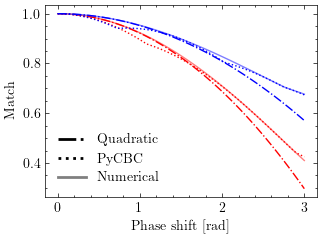

In [8]:
length_arr = 101
dphi_arr = -np.linspace(1e-3, 3, length_arr)

plt.figure(figsize=(3.5, 2.5))
[match_plot(fres, phase_shift, dphi_arr, color) for fres, color in frequency_colors.items()]
#plt.yscale('log') 

line_types = {'-.': 'Quadratic',':':'PyCBC','-': 'Numerical'}
style_handles = []
for ls, label in line_types.items():
    alpha = 0.5 if ls == '-' else 1.0  # only the solid line is semi-transparent
    handle = Line2D([0], [0], color='black', linestyle=ls, lw=2, alpha=alpha)
    style_handles.append(handle)

style_labels = list(line_types.values())

plt.legend(handles=style_handles, labels=style_labels, loc='lower left')

#plt.title(f"Red: $f_{{res}}=50Hz$. Blue: $f_{{res}}=100Hz$")
plt.xlabel('Phase shift [rad]')
plt.ylabel('Match')
plt.savefig(os.path.join(figures_path, f'approx_phase_shift.png'), bbox_inches='tight', dpi=300)
plt.show()
